# 07_Pipeline.ipynb

## Section 1 — Introduction

---

# What is a Pipeline?

A **Pipeline** is a scikit-learn utility that **chains multiple preprocessing steps and a machine learning model into a single object**.

Instead of manually performing each step one by one, the pipeline executes them in the correct order.

Without Pipeline:

```text
Dataset
   ↓
Train-Test Split
   ↓
StandardScaler
   ↓
OneHotEncoder
   ↓
Feature Selection
   ↓
Model
```

With Pipeline:

```text
Dataset
   ↓
Pipeline
   ├── StandardScaler
   ├── OneHotEncoder
   ├── Feature Selection
   └── Model
```

---

# Why Do We Need a Pipeline?

Without a pipeline, you'll often write code like this:

```python
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)
```

As preprocessing grows (encoding, scaling, imputation, feature selection), the code becomes repetitive and error-prone.

A Pipeline combines everything into one object:

```python
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
```

---

# Problems Without a Pipeline

| Problem                         | Explanation                                                        |
| ------------------------------- | ------------------------------------------------------------------ |
| Repetitive code                 | Every preprocessing step is written manually                       |
| Data leakage                    | Easy to accidentally fit preprocessing on the entire dataset       |
| Hard to maintain                | Many separate objects to manage                                    |
| Difficult hyperparameter tuning | Parameters from preprocessing and the model are handled separately |
| Less reusable                   | More code to reuse across projects                                 |

---

# How Does a Pipeline Work?

A pipeline executes each step **sequentially**.

```text
Input Data
     │
     ▼
Step 1
(transform)
     │
     ▼
Step 2
(transform)
     │
     ▼
Step 3
(transform)
     │
     ▼
Final Estimator
(fit/predict)
```

### Rules

* Every intermediate step must implement:

  * `fit()`
  * `transform()`
* The final step must implement:

  * `fit()`
  * `predict()` (or another estimator interface)

---

# Mathematical Intuition

Suppose we have:

**`X`**

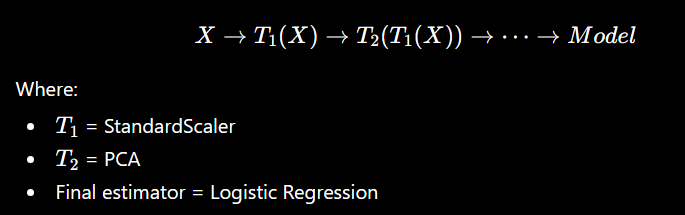

Each transformation takes the output of the previous step as its input.

---

# Advantages

| Advantage                    | Explanation                                         |
| ---------------------------- | --------------------------------------------------- |
| Cleaner code                 | One object manages the entire workflow              |
| Prevents data leakage        | Training-only transformations are handled correctly |
| Easy to reuse                | Save and apply the whole workflow                   |
| Integrates with GridSearchCV | Tune preprocessing and model together               |
| Easier deployment            | Preprocessing and prediction stay synchronized      |

---

# Disadvantages

| Disadvantage                       | Explanation                                                                                       |
| ---------------------------------- | ------------------------------------------------------------------------------------------------- |
| Less flexible for custom branching | Standard `Pipeline` is linear (use `ColumnTransformer` or custom code for more complex workflows) |
| Debugging intermediate outputs     | Slightly harder than separate steps                                                               |
| Learning curve                     | Requires understanding transformers vs estimators                                                 |

---

# When to Use

Use a Pipeline when:

* Applying multiple preprocessing steps.
* Training any scikit-learn model.
* Using `Cross Validation`.
* Using `GridSearchCV`.
* Preparing a model for deployment.

---

# When NOT to Use

Avoid a simple Pipeline when:

* You need complex branching transformations (consider `ColumnTransformer` or `FeatureUnion`).
* Your preprocessing depends on external logic outside the pipeline.
* You are only experimenting with a single quick preprocessing step.

---

# Applications

| Domain          | Example                            |
| --------------- | ---------------------------------- |
| Healthcare      | Scale → PCA → Logistic Regression  |
| Finance         | Impute → Scale → Random Forest     |
| NLP             | Vectorizer → TF-IDF → Naive Bayes  |
| Computer Vision | Feature Extraction → Classifier    |
| Marketing       | Encode → Scale → Gradient Boosting |

---

# Pipeline vs Manual Workflow

| Manual Workflow                  | Pipeline                  |
| -------------------------------- | ------------------------- |
| Multiple preprocessing objects   | Single object             |
| More code                        | Less code                 |
| Easier to introduce data leakage | Helps prevent leakage     |
| Harder to tune                   | Easy with `GridSearchCV`  |
| Harder to deploy                 | Easier to save and deploy |

---

# Key Takeaways

* A Pipeline combines preprocessing and the model into **one workflow**.
* It executes steps **in sequence**.
* It reduces code duplication and helps prevent **data leakage**.
* It integrates seamlessly with **Cross Validation**, **GridSearchCV**, and model persistence.
* It is considered a **best practice** for almost every scikit-learn project.

# 07_Pipeline.ipynb

# Section 2 — Import & Constructor

Unlike `LogisticRegression` or `StandardScaler`, a **Pipeline** is a container that combines multiple transformers and one final estimator.

---

# Import

```python
from sklearn.pipeline import Pipeline
```

---

# Constructor

```python
Pipeline(
    steps,
    *,
    transform_input=None,
    memory=None,
    verbose=False
)
```

---

# Important Parameters

| Parameter | Default | Description                   | Common Usage    |
| --------- | ------- | ----------------------------- | --------------- |
| `steps`   | —       | List of pipeline steps        | Required        |
| `memory`  | `None`  | Cache fitted transformers     | Large pipelines |
| `verbose` | `False` | Print progress during fitting | Debugging       |

> **Note:** `transform_input` is a newer, advanced parameter used with metadata routing. For most projects and interviews, you won't need it.

---

# 1. steps ⭐⭐⭐⭐⭐

This is the **most important parameter**.

It defines the sequence of operations.

---

## Syntax

```python
steps=[
    ("name1", transformer1),
    ("name2", transformer2),
    ...
    ("model", estimator)
]
```

Notice that every step has **two parts**:

```text
("step_name", object)
```

Example:

```python
("scaler", StandardScaler())
```

---

## Why do we give names?

The names are used to:

* Access individual steps
* Tune hyperparameters in `GridSearchCV`
* Read the pipeline more easily

Example:

```python
("scaler", StandardScaler())

("classifier", LogisticRegression())
```

---

## Complete Example

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression())
    ]
)
```

Pipeline order

```text
Dataset
    ↓
StandardScaler
    ↓
LogisticRegression
```

---

# Rules for Pipeline Steps

Every intermediate step must be a **Transformer**.

A transformer implements:

```python
fit()

transform()
```

Examples:

| Transformer    | Allowed? |
| -------------- | -------- |
| StandardScaler | ✅        |
| MinMaxScaler   | ✅        |
| OneHotEncoder  | ✅        |
| SimpleImputer  | ✅        |
| PCA            | ✅        |

---

The **last step** must be an **Estimator**.

An estimator implements:

```python
fit()

predict()
```

Examples:

| Estimator              | Allowed? |
| ---------------------- | -------- |
| LinearRegression       | ✅        |
| LogisticRegression     | ✅        |
| RandomForestClassifier | ✅        |
| SVC                    | ✅        |

---

### Invalid Pipeline

```python
Pipeline([
    ("model1", LogisticRegression()),
    ("model2", RandomForestClassifier())
])
```

❌ This is invalid because `LogisticRegression` is not a transformer. It cannot pass transformed data to the next step.

---

### Valid Pipeline

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
```

---

# 2. memory

```python
memory=None
```

Used to cache the output of expensive transformers.

Useful when:

* Running `GridSearchCV`
* Running repeated `Cross Validation`
* Large preprocessing pipelines

Example

```python
Pipeline(
    steps=[...],
    memory="cache_folder"
)
```

For most beginner projects:

```text
Keep it as None.
```

---

# 3. verbose

```python
verbose=False
```

If enabled

```python
verbose=True
```

Pipeline prints progress while fitting.

Example output

```text
[Pipeline] ........ scaler
[Pipeline] ........ classifier
```

Useful for:

* Large datasets
* Debugging
* Long training times

---

# Creating a Pipeline

The most common pipeline:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
```

This is equivalent to:

```python
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train, y_train)

model.predict(X_test)
```

But much cleaner.

---

# Naming Convention

Although any name works, these are common conventions.

| Step                   | Common Name    |
| ---------------------- | -------------- |
| StandardScaler         | `"scaler"`     |
| MinMaxScaler           | `"minmax"`     |
| OneHotEncoder          | `"encoder"`    |
| PCA                    | `"pca"`        |
| SimpleImputer          | `"imputer"`    |
| LogisticRegression     | `"classifier"` |
| LinearRegression       | `"regressor"`  |
| RandomForestClassifier | `"classifier"` |

Example

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
```

---

# Recommended Settings

### Classification

```python
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
```

---

### Regression

```python
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])
```

---

# Constructor Summary

| Parameter | Recommended Value |
| --------- | ----------------- |
| `steps`   | Required          |
| `memory`  | `None`            |
| `verbose` | `False`           |

---

# Key Takeaways

* `steps` is the heart of a Pipeline.
* Every step is a tuple: `("name", object)`.
* Intermediate steps must implement `fit()` and `transform()`.
* The final step must be an estimator (e.g., `LogisticRegression`, `LinearRegression`).
* `memory` is useful for caching in large workflows but is rarely needed for beginner projects.
* `verbose=True` prints progress during training and is mainly useful for debugging.

# 07_Pipeline.ipynb

# Section 3 — Methods & Attributes

A `Pipeline` behaves like a normal scikit-learn model.

You don't separately call `fit()` on the scaler and then on the model. Instead, you call methods on the **Pipeline object**, and it automatically executes each step in order.

---

# Important Methods

| Method                 | Purpose                                                | Returns          |
| ---------------------- | ------------------------------------------------------ | ---------------- |
| `fit(X, y)`            | Train all pipeline steps                               | `self`           |
| `predict(X)`           | Predict using the trained pipeline                     | NumPy array      |
| `predict_proba(X)`     | Predict probabilities (if final estimator supports it) | NumPy array      |
| `score(X, y)`          | Evaluate the final estimator                           | Float            |
| `transform(X)`         | Transform data (if final step is a transformer)        | Transformed data |
| `fit_transform(X)`     | Fit and transform                                      | Transformed data |
| `inverse_transform(X)` | Reverse transformations (if supported)                 | Original data    |
| `get_params()`         | Get pipeline parameters                                | Dictionary       |
| `set_params()`         | Update pipeline parameters                             | `self`           |

---

# 1. fit()

Trains the entire pipeline.

## Syntax

```python
pipe.fit(X_train, y_train)
```

---

## What happens internally?

Suppose the pipeline is:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])
```

Calling

```python
pipe.fit(X_train, y_train)
```

internally performs:

```text
Step 1

StandardScaler.fit(X_train)

↓

StandardScaler.transform(X_train)

↓

Step 2

LogisticRegression.fit(
    scaled_X_train,
    y_train
)
```

Everything happens automatically.

---

# 2. predict()

Predicts using the trained pipeline.

```python
y_pred = pipe.predict(X_test)
```

Internally

```text
X_test

↓

StandardScaler.transform()

↓

LogisticRegression.predict()

↓

Predictions
```

You never need to manually scale the test data.

---

# 3. predict_proba()

Available only if the final estimator supports probability prediction.

Example

```python
prob = pipe.predict_proba(X_test)
```

Output

```text
[
 [0.02 0.98]
 [0.91 0.09]
]
```

Useful for:

* ROC Curve
* ROC AUC
* Log Loss

---

# 4. score()

Returns the default score of the final estimator.

Example

```python
pipe.score(X_test, y_test)
```

Returns

| Final Estimator        | Returned Score |
| ---------------------- | -------------- |
| LinearRegression       | R² Score       |
| LogisticRegression     | Accuracy       |
| RandomForestClassifier | Accuracy       |

---

# 5. transform()

Only available if the **final step is also a transformer**.

Example

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])
```

Now

```python
X_new = pipe.transform(X_test)
```

works.

---

If the last step is

```python
LogisticRegression()
```

then

```python
pipe.transform()
```

❌ is **not available** because `LogisticRegression` is an estimator, not a transformer.

---

# 6. fit_transform()

Fits and transforms in one step.

```python
X_new = pipe.fit_transform(X_train)
```

Again, this only works when the pipeline ends with a transformer.

---

# 7. inverse_transform()

Reverses transformations.

Example

```python
Pipeline([
    ("scaler", StandardScaler())
])
```

```python
scaled = pipe.fit_transform(X)

original = pipe.inverse_transform(scaled)
```

Useful when you need the original feature values after preprocessing.

Only works if every transformer in the pipeline supports `inverse_transform()`.

---

# 8. get_params()

Returns every parameter of every step.

```python
params = pipe.get_params()
```

Example output

```python
{
 'classifier__C':1.0,
 'classifier__max_iter':500,
 'scaler__with_mean':True,
 ...
}
```

Notice the naming pattern:

```text
step_name__parameter
```

(double underscore)

---

# 9. set_params()

Updates parameters.

Example

```python
pipe.set_params(
    classifier__C=0.5
)
```

Notice

```text
classifier__C
```

This is extremely important because **GridSearchCV uses exactly this syntax**.

---

# Pipeline Attributes

Unlike models such as `LogisticRegression`, `Pipeline` has very few attributes.

---

## Important Attributes

| Attribute           | Description                                           |
| ------------------- | ----------------------------------------------------- |
| `steps`             | List of pipeline steps                                |
| `named_steps`       | Dictionary of named steps                             |
| `feature_names_in_` | Input feature names (after fitting, if supported)     |
| `classes_`          | Classes learned by the final estimator (if supported) |
| `n_features_in_`    | Number of input features                              |

---

# 1. steps

Returns the original step list.

```python
pipe.steps
```

Output

```python
[
 ('scaler', StandardScaler()),
 ('classifier', LogisticRegression())
]
```

---

# 2. named_steps ⭐⭐⭐⭐⭐

One of the most useful attributes.

Instead of indexing,

```python
pipe.steps[0]
```

you can access by name.

```python
pipe.named_steps["scaler"]
```

or

```python
pipe.named_steps["classifier"]
```

Example

```python
print(
    pipe.named_steps["classifier"].coef_
)
```

This accesses the Logistic Regression model **inside the pipeline**.

---

# 3. feature_names_in_

Available after fitting (when supported).

```python
pipe.feature_names_in_
```

Example

```text
['age',
 'salary',
 'experience']
```

---

# 4. classes_

Returns the learned class labels.

```python
pipe.classes_
```

Example

```text
array([0,1])
```

Equivalent to

```python
pipe.named_steps[
    "classifier"
].classes_
```

---

# 5. n_features_in_

Returns the number of input features.

```python
pipe.n_features_in_
```

Example

```text
30
```

---

# Complete Example

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)

prob = pipe.predict_proba(X_test)

print(pipe.score(X_test, y_test))

print(pipe.steps)

print(pipe.named_steps["classifier"])

print(pipe.get_params())
```

---

# Summary

## Methods

| Method                | Most Used? |
| --------------------- | ---------- |
| `fit()`               | ⭐⭐⭐⭐⭐      |
| `predict()`           | ⭐⭐⭐⭐⭐      |
| `predict_proba()`     | ⭐⭐⭐⭐       |
| `score()`             | ⭐⭐⭐⭐       |
| `get_params()`        | ⭐⭐⭐⭐       |
| `set_params()`        | ⭐⭐⭐⭐       |
| `transform()`         | ⭐⭐⭐        |
| `fit_transform()`     | ⭐⭐⭐        |
| `inverse_transform()` | ⭐⭐         |

---

## Attributes

| Attribute           | Most Used? |
| ------------------- | ---------- |
| `steps`             | ⭐⭐⭐⭐       |
| `named_steps`       | ⭐⭐⭐⭐⭐      |
| `classes_`          | ⭐⭐⭐        |
| `feature_names_in_` | ⭐⭐⭐        |
| `n_features_in_`    | ⭐⭐⭐        |

---

## ⭐ Interview Tip

A very common interview question is:

**Q:** *How do you access the Logistic Regression model inside a Pipeline?*

**Answer:**

```python
pipe.named_steps["classifier"]
```

Then you can access any model attribute, for example:

```python
pipe.named_steps["classifier"].coef_
```

# 07_Pipeline.ipynb

# Section 4 — End-to-End Workflow

In this section, we'll build a complete machine learning workflow using a **Pipeline**.

We'll use:

* **Dataset:** Breast Cancer Dataset
* **Preprocessing:** StandardScaler
* **Model:** LogisticRegression

This is the most common pipeline you'll see in scikit-learn projects.

---

# Workflow Diagram

```text id="4dlnpg"
Load Dataset
      │
      ▼
Train-Test Split
      │
      ▼
Create Pipeline
      │
      ▼
fit()
      │
      ▼
(StandardScaler.fit)
      │
      ▼
(StandardScaler.transform)
      │
      ▼
(LogisticRegression.fit)
      │
      ▼
predict()
      │
      ▼
Evaluate
```

---

# Step 1 — Import Libraries

```python id="79lrxa"
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
```

---

# Step 2 — Load Dataset

```python id="u0h8mf"
data = load_breast_cancer()

X = data.data
y = data.target
```

---

# Step 3 — Train-Test Split

```python id="jw7mvu"
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

---

# Step 4 — Create Pipeline

```python id="l8qcrw"
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=500
    ))
])
```

Pipeline:

```text id="y34mqj"
X
 │
 ▼
StandardScaler
 │
 ▼
LogisticRegression
 │
 ▼
Prediction
```

---

# Step 5 — Train Pipeline

Instead of training each step separately:

```python id="7hnsu0"
pipe.fit(X_train, y_train)
```

Internally, Pipeline performs:

```text id="1sl48l"
StandardScaler.fit(X_train)

↓

StandardScaler.transform(X_train)

↓

LogisticRegression.fit()
```

All of this happens automatically.

---

# Step 6 — Make Predictions

```python id="8k8o37"
y_pred = pipe.predict(X_test)
```

Internally:

```text id="y27qnh"
X_test

↓

StandardScaler.transform()

↓

LogisticRegression.predict()

↓

Predictions
```

Notice that **you never call `transform()` yourself**.

---

# Step 7 — Evaluate Model

```python id="m30shg"
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
```

Example output:

```text id="0f6vki"
Accuracy: 0.9737
```

---

# Complete Code

```python id="hh0r95"
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=500
    ))
])

# Train
pipe.fit(X_train, y_train)

# Predict
y_pred = pipe.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
```

---

# Manual Workflow vs Pipeline

### Without Pipeline

```python id="hmj8fd"
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

### With Pipeline

```python id="f32dcb"
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
```

The pipeline version is shorter, cleaner, and automatically prevents common preprocessing mistakes.

---

# Accessing Individual Steps

```python id="phx2o8"
pipe.named_steps["scaler"]

pipe.named_steps["classifier"]
```

Example:

```python id="bqcvcl"
print(
    pipe.named_steps["classifier"].coef_
)
```

This is useful when you need information from the trained model inside the pipeline.

---

# Important Notes

| Note                                                                         | Explanation                                               |
| ---------------------------------------------------------------------------- | --------------------------------------------------------- |
| Split before fitting the pipeline                                            | Prevents data leakage.                                    |
| Call `fit()` only once on the pipeline                                       | It trains every step in the correct order.                |
| Call `predict()` on the pipeline                                             | It automatically applies preprocessing before prediction. |
| The last step must be an estimator                                           | Intermediate steps must be transformers.                  |
| The pipeline can be passed directly to `cross_val_score()` or `GridSearchCV` | No extra preprocessing code is needed.                    |

---

# Common Errors

| Mistake                                                              | Why It Happens                                          | Solution                                                                 |
| -------------------------------------------------------------------- | ------------------------------------------------------- | ------------------------------------------------------------------------ |
| Using two estimators in one Pipeline                                 | Only the last step can be an estimator                  | Create separate pipelines or use `VotingClassifier`/`StackingClassifier` |
| Calling `transform()` on a pipeline ending with `LogisticRegression` | The final estimator is not a transformer                | Use `predict()` instead                                                  |
| Manually scaling data before `Pipeline.fit()`                        | Results in duplicate preprocessing                      | Let the pipeline handle scaling                                          |
| Forgetting to name pipeline steps                                    | Makes parameter tuning harder                           | Give each step a meaningful name like `"scaler"` or `"classifier"`       |
| Expecting `Pipeline` to skip preprocessing during prediction         | Pipeline always applies preprocessing before prediction | Simply call `pipe.predict()`                                             |

---

# Why Pipeline is Important

Without a pipeline, you are responsible for ensuring that:

* Training data is scaled correctly.
* Test data is transformed using the **same scaler**.
* The preprocessing order is consistent.

A pipeline automates all of this, making your code:

* Cleaner
* Less error-prone
* Easier to tune with `GridSearchCV`
* Easier to deploy and reuse

This is why using a `Pipeline` is considered a **best practice** in scikit-learn.

## **Practice**

In [18]:
from sklearn.datasets import load_wine
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [19]:
raw = load_wine(as_frame=True)
df = raw.frame

df.head(10)
df['target'].value_counts()

X = df.drop('target' , axis = 1)
y = df['target']

X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    shuffle=True,
    test_size= 0.3
)

pipe = Pipeline(
    steps= [
        ('scaler' , StandardScaler(with_std=True , with_mean=True)),
        ('classifier' , LogisticRegression(class_weight='balanced' , random_state=42 , max_iter=500))
    ],
    verbose= True
)

pipe.fit(X_train , y_train)
print(pipe.score(X_test , y_test))

pipe.set_params(
    classifier__class_weight = None
)

pipe.score(X_test , y_test)


[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   0.0s
0.9814814814814815


0.9814814814814815

# 07_Pipeline.ipynb

# Section 5 — Interview Questions & Hands-on Project

---

# Interview Questions

### 1. What is a Pipeline in scikit-learn?

**Answer:**

A Pipeline is a scikit-learn object that chains multiple preprocessing steps and a final estimator into a single workflow. It automates preprocessing and model training in the correct order.

---

### 2. Why should we use a Pipeline?

**Answer:**

A Pipeline:

* Reduces repetitive code.
* Prevents data leakage.
* Makes code cleaner and easier to maintain.
* Works seamlessly with `Cross Validation` and `GridSearchCV`.
* Simplifies model deployment.

---

### 3. What are the requirements for the steps in a Pipeline?

**Answer:**

* Every **intermediate step** must be a **Transformer**, implementing `fit()` and `transform()`.
* The **final step** must be an **Estimator**, implementing `fit()` and `predict()` (or another prediction interface).

---

### 4. Can a Pipeline contain multiple estimators?

**Answer:**

No. A standard Pipeline can contain **only one final estimator**.

To use multiple models together, use meta-estimators like:

* `VotingClassifier`
* `StackingClassifier`
* `BaggingClassifier`

or create separate pipelines.

---

### 5. What is the difference between a Transformer and an Estimator?

**Answer:**

| Transformer                          | Estimator                              |
| ------------------------------------ | -------------------------------------- |
| Implements `fit()` and `transform()` | Implements `fit()` and `predict()`     |
| Transforms input data                | Learns from data and makes predictions |
| Example: `StandardScaler`            | Example: `LogisticRegression`          |

---

### 6. Why does a Pipeline help prevent data leakage?

**Answer:**

During training, the Pipeline fits preprocessing steps (e.g., `StandardScaler`) **only on the training data**. During prediction, it uses the learned parameters to transform the test data without refitting, preventing information from the test set from leaking into training.

---

### 7. What does `pipe.fit(X_train, y_train)` do internally?

**Answer:**

It executes each step in sequence:

1. `StandardScaler.fit(X_train)`
2. `StandardScaler.transform(X_train)`
3. `LogisticRegression.fit(scaled_X_train, y_train)`

All intermediate transformations happen automatically.

---

### 8. How do you access the model inside a Pipeline?

**Answer:**

Use the `named_steps` attribute.

Example:

```python
pipe.named_steps["classifier"]
```

To access model coefficients:

```python
pipe.named_steps["classifier"].coef_
```

---

### 9. How do you change a parameter of a model inside a Pipeline?

**Answer:**

Use `set_params()` with the format:

```python
step_name__parameter=value
```

Example:

```python
pipe.set_params(
    classifier__C=0.5
)
```

After changing the parameter, call `fit()` again to retrain the pipeline.

---

### 10. What is the difference between `steps` and `named_steps`?

**Answer:**

| `steps`                                   | `named_steps`                                  |
| ----------------------------------------- | ---------------------------------------------- |
| Returns a list of `(name, object)` tuples | Returns a dictionary of step names and objects |
| Access by index                           | Access by step name                            |
| Example: `pipe.steps[0]`                  | Example: `pipe.named_steps["scaler"]`          |
